# 07 — XGBoost
Walk-forward XGBoost on weekly silver log-returns with lagged features.
Same train/val/test split and evaluation metrics as the ARIMA and LSTM notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [2]:
train = pd.read_csv('../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../data/processed/test.csv',  index_col=0, parse_dates=True)

TARGET = 'silver_return'
EXOG   = ['gold_return', 'usd_return', 'copper_return', 'sp500_return']

# Aggregate daily → weekly (log returns are additive, exog averaged)
agg = {TARGET: 'sum'}
for c in EXOG:
    agg[c] = 'sum'

def to_weekly(df):
    return df[list(agg.keys())].resample('W-FRI').agg(agg).dropna()

train_w = to_weekly(train)
val_w   = to_weekly(val)
test_w  = to_weekly(test)

# Combine for walk-forward: model trains on all data up to the forecast week
all_w = pd.concat([train_w, val_w, test_w])
n_train = len(train_w) + len(val_w)   # test starts here

print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')

Weekly obs — train+val: 417, test: 175


## 2. Feature matrix

XGBoost is not a sequential model — it needs an explicit feature matrix.
Each row is week $t$; features are week $t-1$ values (lagged by one week) so there
is no lookahead. We also include lags 2 and 3 of silver return to give the model
a short memory window.

In [3]:
def build_features(df):
    X = pd.DataFrame(index=df.index)
    # Lagged market returns (1 week back)
    for col in EXOG:
        X[f'{col}_lag1'] = df[col].shift(1)
    # Lagged silver return (1, 2, 3 weeks back)
    for lag in [1, 2, 3]:
        X[f'silver_lag{lag}'] = df[TARGET].shift(lag)
    return X

features_all = build_features(all_w)
feature_cols = features_all.columns.tolist()
print('Features:', feature_cols)

Features: ['gold_return_lag1', 'usd_return_lag1', 'copper_return_lag1', 'sp500_return_lag1', 'silver_lag1', 'silver_lag2', 'silver_lag3']


## 3. Walk-forward forecast

At each test week $t$ we train XGBoost on all weeks before $t$ (expanding window),
then predict week $t$. This mirrors the rolling ARIMAX setup.

In [4]:
def walk_forward(all_w, features_all, n_train, feature_cols, **xgb_kwargs):
    y_all = all_w[TARGET].values
    X_all = features_all[feature_cols].values

    preds = np.full(len(all_w) - n_train, np.nan)

    for i, t in enumerate(range(n_train, len(all_w))):
        X_tr = X_all[:t]
        y_tr = y_all[:t]
        X_te = X_all[t:t+1]

        # Drop rows with NaN (first few weeks have no lag history)
        mask = ~np.isnan(X_tr).any(axis=1)
        if mask.sum() < 10 or np.isnan(X_te).any():
            continue

        model = XGBRegressor(random_state=42, verbosity=0, **xgb_kwargs)
        model.fit(X_tr[mask], y_tr[mask])
        preds[i] = model.predict(X_te)[0]

    return preds

print('Running walk-forward XGBoost...')
preds_xgb = walk_forward(
    all_w, features_all, n_train, feature_cols,
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8
)
print('Done')

Running walk-forward XGBoost...
Done


## 4. Evaluate

In [5]:
y_test = all_w[TARGET].iloc[n_train:].values
test_index = all_w.index[n_train:]

def evaluate(name, y_true, y_pred):
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    if mask.sum() == 0:
        print(f'{name:40s}  No valid predictions')
        return None
    y_t, y_p = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    da   = np.mean(np.sign(y_t) == np.sign(y_p))
    wda  = np.sum(np.abs(y_t) * (np.sign(y_t) == np.sign(y_p))) / np.sum(np.abs(y_t))
    print(f'{name:40s}  RMSE={rmse:.5f}  MAE={mae:.5f}  DA={da:.3f}  WDA={wda:.3f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}

naive_pred = all_w[TARGET].iloc[n_train-1:-1].values  # last week's return

metrics = []
metrics.append(evaluate('Naive (t-1 week)',  y_test[1:], naive_pred[1:]))
metrics.append(evaluate('XGBoost',           y_test,     preds_xgb))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../data/processed/metrics_xgboost.csv', index=False)
metrics_df

Naive (t-1 week)                          RMSE=0.07584  MAE=0.05386  DA=0.494  WDA=0.491
XGBoost                                   RMSE=0.05321  MAE=0.03836  DA=0.503  WDA=0.480


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075840,0.053865,0.494253,0.491093
1,XGBoost,0.053213,0.038360,0.502857,0.479747


## 5. Predicted vs actual

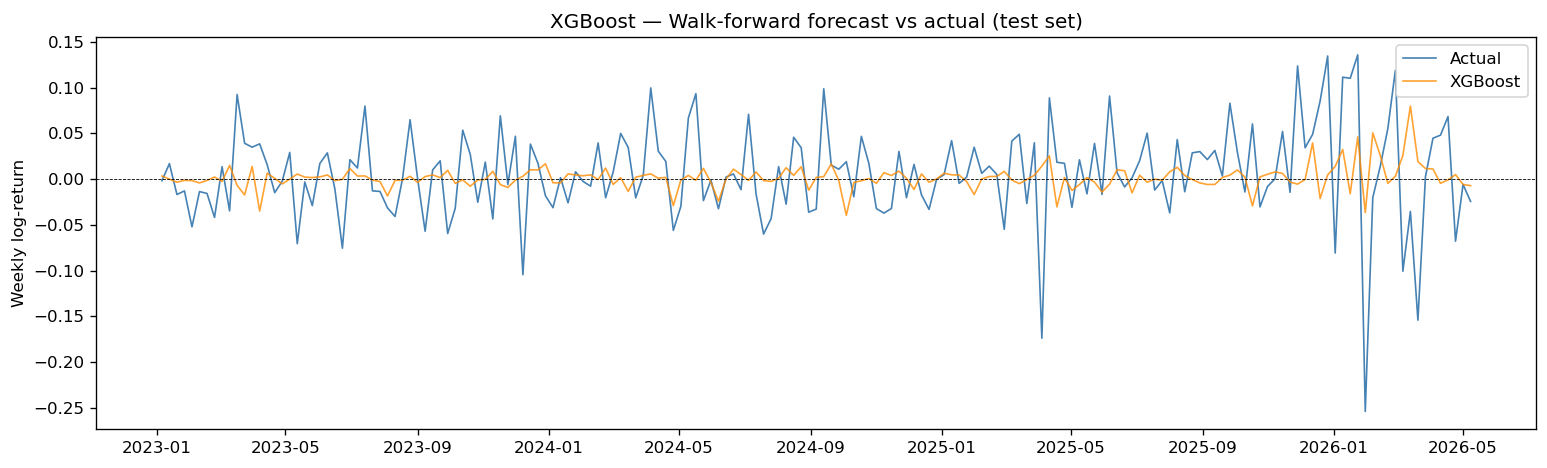

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test,   lw=1,   label='Actual',   color='steelblue')
ax.plot(test_index, preds_xgb, lw=1, label='XGBoost',  color='darkorange', alpha=0.8)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('XGBoost — Walk-forward forecast vs actual (test set)')
ax.set_ylabel('Weekly log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature importance

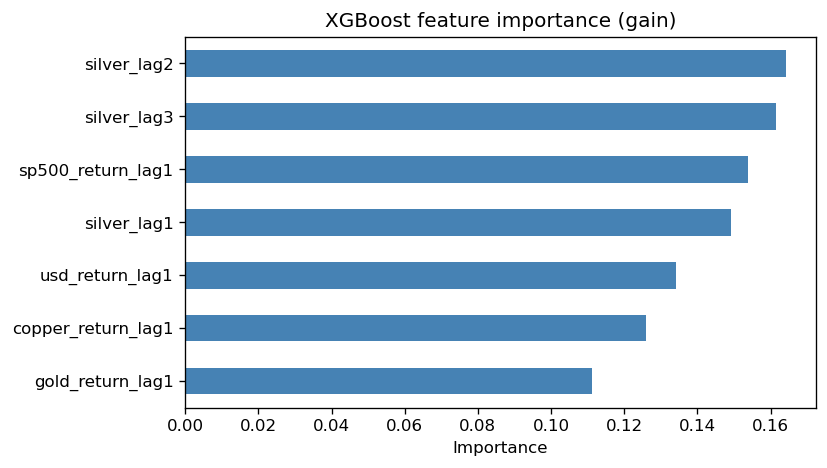

silver_lag2           0.164211
silver_lag3           0.161429
sp500_return_lag1     0.153898
silver_lag1           0.149177
usd_return_lag1       0.134142
copper_return_lag1    0.125843
gold_return_lag1      0.111299
dtype: float32


In [7]:
# Retrain on full train+val to get stable importance scores
X_all = features_all[feature_cols].values
y_all = all_w[TARGET].values
mask  = ~np.isnan(X_all[:n_train]).any(axis=1)

final_model = XGBRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
final_model.fit(X_all[:n_train][mask], y_all[:n_train][mask])

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('XGBoost feature importance (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))